[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter13_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 13: Speculative bubbles and LPPL models

*Lecture notebook (self-study chapter). Daniel Traian Pele, Bucharest University of Economic Studies.*

- Six run-ups and crashes in the course data: S&P 500 and Nasdaq 100 (2000), BET (2007), Shanghai Composite (2015), Bitcoin (2017, 2021).
- Rational bubbles and explosive roots: right-tailed ADF, SADF, GSADF and BSADF date-stamping.
- The LPPL model of Johansen, Ledoit and Sornette; estimation by the two-step method of Filimonov and Sornette.
- Confidence from many windows (the LPPLS confidence indicator) and an honest evaluation of crash prediction.
- The first code cell installs the `arch` package if it is missing (`pip install arch`).
- References: Blanchard and Watson (1982); Phillips, Wu and Yu (2011); Phillips, Shi and Yu (2015); Johansen, Ledoit and Sornette (2000); Filimonov and Sornette (2013); Shu and Zhu (2020).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_13'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
# The arch package (Phillips-Perron test of the LPPL residuals) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- `psy(y)`: ADF, SADF, GSADF and the BSADF sequence of a log price; `psy_cv(T, w0)`: Monte Carlo critical values.
- `lppl_fit(t, y)`: LPPL calibration (OLS for A, B, C1, C2; grid search and Nelder–Mead for tc, m, omega); `t` in decimal years, `y` the log price.
- `lppl_conditions(fit)`: the filter conditions of Shu and Zhu (2020); `qualified(c, 'param' | 'full')`.
- `confidence_series(s, start, end)`: the LPPLS confidence indicator; `cached_ci` reads the series computed for the slides (`Quantlets/Ch_13/ch13_ci_*.csv`), because the full computation takes several minutes.

In [6]:
from scipy.signal import lombscargle
SEED = 2026
EPISODES = {'sp500': {'label': 'S&P 500, 2000', 'symbol': 'GSPC.INDX', 'crypto': False, 'low': ('1998-08-01', '1998-11-30'), 'peak': ('1999-06-01', '2000-12-31')}, 'ndx': {'label': 'Nasdaq 100, 2000', 'symbol': 'NDX.INDX', 'crypto': False, 'low': ('1998-08-01', '1998-11-30'), 'peak': ('1999-06-01', '2000-12-31')}, 'bet': {'label': 'BET, 2007', 'symbol': 'BET', 'crypto': False, 'low': ('2006-05-01', '2006-08-31'), 'peak': ('2007-01-01', '2007-12-31')}, 'ssec': {'label': 'Shanghai Composite, 2015', 'symbol': 'SSEC.INDX', 'crypto': False, 'low': ('2014-03-01', '2014-07-31'), 'peak': ('2015-01-01', '2015-12-31')}, 'btc17': {'label': 'Bitcoin, 2017', 'symbol': 'BTC-USD.CC', 'crypto': True, 'low': ('2016-12-01', '2017-03-31'), 'peak': ('2017-06-01', '2018-03-31')}, 'btc21': {'label': 'Bitcoin, 2021', 'symbol': 'BTC-USD.CC', 'crypto': True, 'low': ('2020-08-01', '2020-10-31'), 'peak': ('2021-01-01', '2021-06-30')}}
COLORS = {'sp500': st.COL['sp500'], 'ndx': st.Teal, 'bet': st.Orange, 'ssec': st.Purple, 'btc17': st.COL['btc'], 'btc21': st.COL['btc']}
FIT_LAG_DAYS = 30
PSY_SAMPLES = {'ndx': ('NDX.INDX', False, '1990-01-01', '2004-12-31'), 'btc': ('BTC-USD.CC', True, '2014-09-17', '2023-12-31'), 'bet': ('BET', False, '2000-01-01', '2012-12-31'), 'ssec': ('SSEC.INDX', False, '2010-01-01', '2018-12-31')}
PSY_LABEL = {'ndx': 'Nasdaq 100', 'btc': 'Bitcoin', 'bet': 'BET', 'ssec': 'Shanghai Composite'}
PSY_REPS = 1000
LPPLS_SEARCH = {'m': (0.0, 1.0), 'w': (1.0, 50.0), 'tc_frac': (0.0, 0.3333333333333333), 'damping_min': 1.0}
LPPLS_FILTER = {'m': (0.01, 0.99), 'w': (2.0, 25.0), 'tc_frac': (0.0, 0.2), 'osc_min': 2.5, 'rel_err_max': 0.15, 'lomb_alpha': 0.1, 'ar1_alpha': 0.1}
WINDOWS = list(range(750, 45, -25))
CI_STEP = 5
CRASH, HORIZON = 0.2, 182
CI_LEVEL = 0.2
EVAL_SAMPLES = {'sp500': ('GSPC.INDX', False, '1993-01-01'), 'btc': ('BTC-USD.CC', True, '2014-01-01')}
PARAM_KEYS = ('B', 'm', 'w', 'tc', 'osc', 'damping')
HERE = next((p for p in ("../../Quantlets/Ch_13", "Quantlets/Ch_13", ".") if os.path.isdir(p)), ".")


def prices(symbol, crypto=False):
    """Daily close of a symbol of data/market, with the course conventions (weekdays only and no holiday-filled
    closes, except for crypto assets)."""
    s = read_market(symbol)['close']
    s = pd.to_numeric(s, errors='coerce').dropna()
    s = s[s > 0]
    if not crypto:
        s = s[s.index.dayofweek < 5]
        s = s[s.diff() != 0]
    return s.rename(symbol)


def weekly(s):
    """Weekly log price: last close of each week (Friday)."""
    return np.log(s.resample('W-FRI').last().dropna())


def yrs(idx):
    """Dates as decimal years (the time unit of the LPPL fits)."""
    idx = pd.DatetimeIndex(idx)
    return np.asarray(idx.year + (idx.dayofyear - 1) / 365.25, float)


def todate(x):
    """Decimal year -> date."""
    y = int(np.floor(x))
    return pd.Timestamp(y, 1, 1) + pd.Timedelta(days=float((x - y) * 365.25))


def d2s(d):
    return pd.Timestamp(d).strftime('%Y-%m-%d')


def episode(key):
    """Series, low before the run-up, peak and ex-ante end date of one episode."""
    e = EPISODES[key]
    s = prices(e['symbol'], e['crypto'])
    low = s.loc[e['low'][0]:e['low'][1]].idxmin()
    peak = s.loc[e['peak'][0]:e['peak'][1]].idxmax()
    t2 = s.loc[:peak - pd.Timedelta(days=FIT_LAG_DAYS)].index[-1]
    return s, low, peak, t2


def drawdown(p):
    """Fall from the previous peak: p_t / max_{s<=t} p_s - 1."""
    return p / p.cummax() - 1


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def _cums(y):
    """Cumulative sums for the regression Delta y_t = a + delta y_{t-1} (rows t = 1..n); y may be (n+1,) or (R, n+1)."""
    y = np.atleast_2d(np.asarray(y, float))
    x, z = y[:, :-1], np.diff(y, axis=1)
    pad = lambda a: np.concatenate([np.zeros((a.shape[0], 1)), np.cumsum(a, axis=1)], axis=1)   # noqa: E731
    return pad(x), pad(x * x), pad(z), pad(z * z), pad(x * z)


def _adf_end(C, e, s):
    """t-statistic of delta for the windows [s, e] (s a vector of start rows), for every replication (rows of C)."""
    Sx, Sxx, Sz, Szz, Sxz = (c[:, e + 1][:, None] - c[:, s] for c in C)
    n = (e + 1 - s).astype(float)
    den = n * Sxx - Sx ** 2
    b = (n * Sxz - Sx * Sz) / den
    a = (Sz - b * Sx) / n
    ssr = np.maximum(Szz - a * Sz - b * Sxz, 1e-300)
    return b / np.sqrt(ssr / (n - 2) * n / den)


def adf_window(y):
    """Right-tailed ADF on one window: delta, its standard error and the t-statistic (OLS written out)."""
    y = np.asarray(y, float)
    x, z = y[:-1], np.diff(y)
    X = np.column_stack([np.ones_like(x), x])
    beta, *_ = np.linalg.lstsq(X, z, rcond=None)
    e = z - X @ beta
    s2 = e @ e / (len(z) - 2)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1])
    return dict(a=float(beta[0]), delta=float(beta[1]), se=float(se), t=float(beta[1] / se), n=len(z))


def min_window(T, r0=None):
    """Smallest window of PSY (2015): r0 = 0.01 + 1.8 / sqrt(T)."""
    r0 = 0.01 + 1.8 / np.sqrt(T) if r0 is None else r0
    return int(np.floor(r0 * T)), r0


def psy(y, r0=None):
    """ADF (whole sample), SADF (sup of forward-expanding ADF), GSADF (sup over start and end points) and the BSADF
    sequence (sup over start points, for each end point) of the log price y."""
    y = np.asarray(y, float)
    n = len(y) - 1
    w0, r0 = min_window(n, r0)
    C = _cums(y)
    bsadf = np.full(n, np.nan)
    fwd = np.full(n, np.nan)
    for e in range(w0 - 1, n):
        stat = _adf_end(C, e, np.arange(0, e - w0 + 2))[0]
        bsadf[e] = stat.max()
        fwd[e] = stat[0]
    return dict(adf=float(fwd[-1]), sadf=float(np.nanmax(fwd)), gsadf=float(np.nanmax(bsadf)), bsadf=bsadf, fwd=fwd,
                w0=w0, r0=r0, n=n)


def psy_cv(T, w0, R=PSY_REPS, seed=SEED, chunk=100):
    """Monte Carlo critical values under a random walk with a weak drift, y_t = T^(-1) + y_{t-1} + e_t (PSY 2015):
    quantiles of ADF, SADF and GSADF, and the 95% quantile of BSADF for each end point."""
    rng = np.random.default_rng(seed)
    Y = np.concatenate([np.zeros((R, 1)), np.cumsum(1.0 / T + rng.standard_normal((R, T)), axis=1)], axis=1)
    bs = np.full((R, T), np.nan)
    fw = np.full((R, T), np.nan)
    for i in range(0, R, chunk):
        C = _cums(Y[i:i + chunk])
        for e in range(w0 - 1, T):
            stat = _adf_end(C, e, np.arange(0, e - w0 + 2))
            bs[i:i + chunk, e] = stat.max(axis=1)
            fw[i:i + chunk, e] = stat[:, 0]
    q = lambda a, p: float(np.quantile(a, p))   # noqa: E731
    return dict(adf={p: q(fw[:, -1], p / 100) for p in (90, 95, 99)},
                sadf={p: q(np.nanmax(fw, axis=1), p / 100) for p in (90, 95, 99)},
                gsadf={p: q(np.nanmax(bs, axis=1), p / 100) for p in (90, 95, 99)},
                bsadf95=np.nanquantile(bs, 0.95, axis=0))


def episodes_above(stat, cv, index, min_len):
    """Date-stamping: periods in which BSADF exceeds its critical value for at least min_len observations."""
    above = np.asarray(stat > cv)
    above[np.isnan(stat) | np.isnan(cv)] = False
    out, i, n = [], 0, len(above)
    while i < n:
        if above[i]:
            j = i
            while j + 1 < n and above[j + 1]:
                j += 1
            if j - i + 1 >= min_len:
                out.append((d2s(index[i]), d2s(index[j]), int(j - i + 1)))
            i = j + 1
        else:
            i += 1
    return out


def run_psy(key):
    """PSY on the weekly log price of one sample: statistics, critical values and dated episodes."""
    sym, crypto, a, b = PSY_SAMPLES[key]
    y = weekly(prices(sym, crypto)).loc[a:b]
    o = psy(y.values)
    cv = psy_cv(o['n'], o['w0'])
    min_len = int(round(np.log(o['n'])))
    ep = episodes_above(o['bsadf'], cv['bsadf95'], y.index[1:], min_len)
    return y, o, cv, ep, min_len


def lppl_design(t, tc, m, w):
    """Columns 1, f, f cos(w ln(tc - t)), f sin(w ln(tc - t)) of the linear part."""
    dt = np.maximum(tc - np.asarray(t, float), 1e-9)
    f = dt ** m
    lg = np.log(dt)
    return np.column_stack([np.ones_like(dt), f, f * np.cos(w * lg), f * np.sin(w * lg)])


def lppl_linear(t, y, tc, m, w):
    """Step 1 of Filimonov-Sornette: for given (tc, m, omega), A, B, C1, C2 by OLS and the sum of squared residuals."""
    X = lppl_design(t, tc, m, w)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    return beta, float(res @ res)


def _damping(m, w, beta):
    C = np.hypot(beta[..., 2], beta[..., 3])
    return m * np.abs(beta[..., 1]) / (w * np.maximum(C, 1e-300))


def _grid(t, y, tcs, ms, ws):
    """SSR of the linear step on a grid of (tc, m, omega), vectorised."""
    TC, M, W = (a.ravel() for a in np.meshgrid(tcs, ms, ws, indexing='ij'))
    dt = np.maximum(TC[:, None] - t[None, :], 1e-9)
    f = dt ** M[:, None]
    lg = np.log(dt)
    X = np.stack([np.ones_like(f), f, f * np.cos(W[:, None] * lg), f * np.sin(W[:, None] * lg)], axis=2)
    XtX = np.einsum('gni,gnj->gij', X, X) + 1e-10 * np.eye(4)
    Xty = np.einsum('gni,n->gi', X, y)
    beta = np.linalg.solve(XtX, Xty[..., None])[..., 0]
    ssr = y @ y - np.einsum('gi,gi->g', beta, Xty)
    return TC, M, W, beta, ssr


def lppl_fit(t, y, search=LPPLS_SEARCH, grid=(8, 8, 16)):
    """Step 2: minimum SSR over the search space (tc in [t2, t2 + (t2 - t1)/3], m in [0, 1], omega in [1, 50],
    damping >= 1): a grid search, then Nelder-Mead from the best grid point. t in years, y = ln p."""
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    t1, t2 = t[0], t[-1]
    D = t2 - t1
    lo = np.array([t2 + search['tc_frac'][0] * D + 1e-6, search['m'][0] + 1e-3, search['w'][0]])
    hi = np.array([t2 + search['tc_frac'][1] * D, search['m'][1] - 1e-3, search['w'][1]])
    TC, M, W, beta, ssr = _grid(t, y, np.linspace(lo[0], hi[0], grid[0]), np.linspace(lo[1], hi[1], grid[1]),
                                np.linspace(lo[2], hi[2], grid[2]))
    ok = _damping(M, W, beta) >= search['damping_min']
    if not ok.any():
        return None
    k = int(np.argmin(np.where(ok, ssr, np.inf)))
    x0 = np.array([TC[k], M[k], W[k]])

    def obj(p):
        q = np.clip(p, lo, hi)
        b, sr = lppl_linear(t, y, *q)
        return sr if _damping(q[1], q[2], b) >= search['damping_min'] else sr + 1e6
    r = optimize.minimize(obj, x0, method='Nelder-Mead', options=dict(xatol=1e-5, fatol=1e-10, maxiter=400))
    if r.fun < 1e6:
        x0 = np.clip(r.x, lo, hi)
    tc, m, w = x0
    (A, B, C1, C2), s = lppl_linear(t, y, tc, m, w)
    C = np.hypot(C1, C2)
    yhat = lppl_design(t, tc, m, w) @ np.array([A, B, C1, C2])
    return dict(tc=float(tc), m=float(m), w=float(w), A=float(A), B=float(B), C1=float(C1), C2=float(C2), C=float(C),
                ssr=float(s), rmse=float(np.sqrt(s / len(t))), damping=float(m * abs(B) / (w * C)) if C > 0 else np.inf,
                osc=float(w / np.pi * np.log((tc - t1) / (tc - t2))),
                rel_err=float(np.max(np.abs(np.exp(yhat) - np.exp(y)) / np.exp(y))), t1=float(t1), t2=float(t2),
                n=len(t), _t=t, _y=y, _yhat=yhat)


def lomb_pvalue(fit, wmin=2.0, wmax=25.0, nw=200):
    """Lomb test: the detrended residual (tc - t)^(-m) (ln p - A - B (tc - t)^m) against ln(tc - t); probability that
    the highest peak of the normalised periodogram arises by chance."""
    from scipy.signal import lombscargle
    t, y = fit['_t'], fit['_y']
    dt = np.maximum(fit['tc'] - t, 1e-9)
    r = dt ** (-fit['m']) * (y - fit['A'] - fit['B'] * dt ** fit['m'])
    x = np.log(dt)
    r = r - r.mean()
    ws = np.linspace(wmin, wmax, nw)
    p = lombscargle(x, r, ws) / r.var()
    return float(1 - (1 - np.exp(-p.max())) ** min(nw, len(r)))


def ar1_pass(fit, alpha):
    """The residual ln p_hat - ln p is stationary (AR(1)): the Dickey-Fuller and Phillips-Perron tests both reject a
    unit root at level alpha (Chapter 3)."""
    from statsmodels.tsa.stattools import adfuller
    from arch.unitroot import PhillipsPerron
    e = fit['_yhat'] - fit['_y']
    return bool(adfuller(e, maxlag=0, autolag=None, regression='c')[1] < alpha and PhillipsPerron(e, trend='c').pvalue < alpha)


def lppl_conditions(fit, flt=LPPLS_FILTER, search=LPPLS_SEARCH):
    """Filter conditions of Shu and Zhu (2020), eq. (12), for a positive bubble (B < 0). The Lomb test runs only when
    the parameter conditions and the relative error pass, the unit-root test of the residual only when Lomb passes."""
    if fit is None:
        return None
    D = fit['t2'] - fit['t1']
    c = dict(B=fit['B'] < 0, m=flt['m'][0] <= fit['m'] <= flt['m'][1], w=flt['w'][0] <= fit['w'] <= flt['w'][1],
             tc=fit['t2'] + flt['tc_frac'][0] * D <= fit['tc'] <= fit['t2'] + flt['tc_frac'][1] * D,
             osc=fit['osc'] >= flt['osc_min'], damping=fit['damping'] >= search['damping_min'],
             rel_err=fit['rel_err'] <= flt['rel_err_max'])
    if all(c.values()):
        c['lomb'] = lomb_pvalue(fit) <= flt['lomb_alpha']
        c['ar1'] = ar1_pass(fit, flt['ar1_alpha']) if c['lomb'] else False
    else:
        c['lomb'] = c['ar1'] = None
    return c


def qualified(c, which='full'):
    """'full': all the conditions (Shu and Zhu 2020); 'param': only the conditions on the parameters."""
    if c is None:
        return False
    keys = PARAM_KEYS if which == 'param' else tuple(c)
    return all(c[k] is True for k in keys)


def lppl_path(fit, t):
    t = np.asarray(t, float)
    return lppl_design(t, fit['tc'], fit['m'], fit['w']) @ np.array([fit['A'], fit['B'], fit['C1'], fit['C2']])


def fit_window(s, t1, t2):
    """LPPL fit of the log price s between the dates t1 and t2 (inclusive)."""
    x = s.loc[t1:t2]
    return lppl_fit(yrs(x.index), np.log(x.values))


def _ci_point(args):
    """Indicator at one end point: shares of qualified fits over the windows (full filter and parameter filter),
    median critical time of the qualified fits."""
    t, y, i2, windows = args
    full, param, tcs = [], [], []
    for L in windows:
        i1 = i2 - L
        if i1 < 0:
            continue
        f = lppl_fit(t[i1:i2 + 1], y[i1:i2 + 1])
        c = lppl_conditions(f)
        full.append(qualified(c, 'full'))
        param.append(qualified(c, 'param'))
        if qualified(c, 'param'):
            tcs.append(f['tc'])
    return (float(np.mean(full)) if full else np.nan, float(np.mean(param)) if param else np.nan,
            float(np.median(tcs)) if tcs else np.nan)


def confidence_series(s, start, end=None, step=CI_STEP, windows=WINDOWS, procs=None):
    """LPPLS confidence indicator (positive bubbles) for the end points t2 in [start, end], every `step` observations.
    procs=1 runs sequentially (notebooks); otherwise a process pool."""
    t, y = yrs(s.index), np.log(s.values)
    idx = np.arange(s.index.searchsorted(pd.Timestamp(start)), len(s) if end is None else s.index.searchsorted(pd.Timestamp(end), 'right'), step)
    jobs = [(t, y, int(i), windows) for i in idx]
    if procs == 1:
        res = [_ci_point(j) for j in jobs]
    else:
        from multiprocessing import get_context
        with get_context('fork').Pool(procs or max(1, os.cpu_count() - 2)) as pool:
            res = pool.map(_ci_point, jobs, chunksize=4)
    return pd.DataFrame(res, index=s.index[idx], columns=['ci_full', 'ci_param', 'tc_median'])


def cached_ci(name, s, start, end=None, step=CI_STEP, recompute=False):
    """The indicator series of the chapter, cached in Quantlets/Ch_13/ch13_ci_<name>.csv (local copy or GitHub)."""
    path = os.path.join(HERE, f'ch13_ci_{name}.csv')
    if not recompute:
        for p in (path, f'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/Quantlets/Ch_13/ch13_ci_{name}.csv'):
            try:
                return pd.read_csv(p, index_col=0, parse_dates=True)
            except Exception:
                pass
    ci = confidence_series(s, start, end, step)
    ci.to_csv(path, float_format='%.4f')
    return ci


def future_fall(s, horizon=HORIZON):
    """For each day t: the largest fall min_{t < u <= t + horizon} p_u / p_t - 1 (NaN when the horizon is not observed)."""
    p = s.values
    d = s.index
    out = np.full(len(s), np.nan)
    j = 0
    for i in range(len(s)):
        lim = d[i] + pd.Timedelta(days=horizon)
        if lim > d[-1]:
            break
        j = max(j, i + 1)
        while j < len(s) and d[j] <= lim:
            j += 1
        out[i] = p[i + 1:j].min() / p[i] - 1 if j > i + 1 else np.nan
    return pd.Series(out, index=d)


def blanchard_watson(T=400, r=0.02, pi=0.98, b0=1.0, sd=0.3, seed=13):
    """Blanchard-Watson bubble: each period it survives with probability pi and then grows by (1 + r)/pi, otherwise it
    bursts (back to noise). E_t[b_{t+1}] = (1 + r) b_t: the expected return equals r."""
    rng = np.random.default_rng(seed)
    b = np.empty(T)
    b[0] = b0
    for t in range(1, T):
        eps = sd * rng.standard_normal()
        b[t] = (1 + r) / pi * b[t - 1] + eps if rng.random() < pi else eps
    return b


def ar1_paths(T=200, rhos=(0.9, 1.0, 1.02), seed=SEED):
    """y_t = rho y_{t-1} + e_t with the same shocks: stationary, unit root and explosive."""
    e = np.random.default_rng(seed).standard_normal(T)
    out = {}
    for rho in rhos:
        y = np.zeros(T)
        for t in range(1, T):
            y[t] = rho * y[t - 1] + e[t]
        out[rho] = y
    return out


def crash_list(s, level=CRASH):
    """Drawdowns of at least 20%: the running peak, the lowest point before the price regains that peak, the size."""
    out = []
    pk_t, pk = s.index[0], s.iloc[0]
    tr_t, tr = pk_t, pk
    for t, p in s.items():
        if p >= pk:
            if tr / pk - 1 <= -level:
                out.append(dict(peak=d2s(pk_t), trough=d2s(tr_t), fall=float(tr / pk - 1)))
            pk_t, pk, tr_t, tr = t, p, t, p
        elif p < tr:
            tr_t, tr = t, p
    if tr / pk - 1 <= -level:
        out.append(dict(peak=d2s(pk_t), trough=d2s(tr_t), fall=float(tr / pk - 1)))
    return out


def hit_rates(d, levels=(0.05, 0.1, 0.2, 0.3, 0.4), col='ci_param'):
    """P(fall >= 20% within 182 days | indicator >= c) against the unconditional frequency."""
    d = d.dropna(subset=['fall'])
    crash = d['fall'] <= -CRASH
    out = dict(base=float(crash.mean()), n=int(len(d)))
    for c in levels:
        a = d[col] >= c
        out[str(c)] = dict(share=float(a.mean()), n=int(a.sum()), hit=float(crash[a].mean()) if a.any() else np.nan)
    return out


def alarm_episodes(d, level=CI_LEVEL, col='ci_param', gap=90):
    """Alarm clusters (days with indicator >= level, separated by fewer than `gap` days) and whether a fall of at
    least 20% follows within 182 days of the first alarm day of each cluster."""
    al = d.index[d[col] >= level]
    out = []
    for t in al:
        if not out or (t - out[-1]['last']).days > gap:
            out.append(dict(first=t, last=t))
        else:
            out[-1]['last'] = t
    for e in out:
        f = d.loc[e['first'], 'fall']
        e['fall'] = None if pd.isna(f) else float(f)
        e['crash'] = None if pd.isna(f) else bool(f <= -CRASH)
    return out


def eval_ci(name):
    """Indicator over the whole sample (S&P 500 since 1993, Bitcoin since 2014) and the fall in the next 182 days."""
    sym, crypto, start = EVAL_SAMPLES[name]
    s = prices(sym, crypto)
    if crypto:
        s = s.loc['2012-01-01':]           # the windows need 750 earlier observations
    ci = cached_ci(f'eval_{name}', s, start, step=7 if crypto else CI_STEP)
    ff = future_fall(s).reindex(ci.index)
    return s, ci.assign(fall=ff)


def episode_ci(key, before=540, after=120):
    s, low, peak, _ = episode(key)
    step = 7 if EPISODES[key]['crypto'] else CI_STEP
    return cached_ci(f'ep_{key}', s, peak - pd.Timedelta(days=before), peak + pd.Timedelta(days=after), step=step), s, peak


def tc_path(key, days_before=240, days_after=30, every=7):
    """Estimated tc as the end of the window t2 moves (start fixed at the low before the run-up)."""
    s, low, peak, _ = episode(key)
    ends = s.loc[peak - pd.Timedelta(days=days_before):peak + pd.Timedelta(days=days_after)].index
    ends = ends[::max(1, every if EPISODES[key]['crypto'] else 5)]
    rows = []
    for t2 in ends:
        f = fit_window(s, low, t2)
        if f is None:
            continue
        rows.append(dict(t2=t2, tc=todate(f['tc']), q=qualified(lppl_conditions(f), 'param')))
    return pd.DataFrame(rows), peak


def windows_at(key):
    """All windows ending at the ex-ante date t2 of one episode: critical time and qualification of each."""
    s, low, peak, t2 = episode(key)
    t, y = yrs(s.index), np.log(s.values)
    i2 = s.index.get_loc(t2)
    rows = []
    for L in WINDOWS:
        f = lppl_fit(t[i2 - L:i2 + 1], y[i2 - L:i2 + 1])
        c = lppl_conditions(f)
        if f is not None:
            rows.append(dict(L=L, tc=todate(f['tc']), q_param=qualified(c, 'param'), q_full=qualified(c, 'full'),
                             **{'c_' + kk: (None if v is None else bool(v)) for kk, v in c.items()}))
    return pd.DataFrame(rows), peak, t2


def worked_examples():
    """Numbers of the worked examples: a rational bubble's growth, explosive AR(1), an LPPL value by hand."""
    A, B, C, m, w, tc, phi = 8.0, -1.2, 0.08, 0.5, 8.0, 2.0, 0.0
    out = {}
    for t in (0.0, 1.0, 1.75, 1.99):
        dt = tc - t
        out[f'{t}'] = dict(dt=dt, fm=dt ** m, lg=float(np.log(dt)), cos=float(np.cos(w * np.log(dt) - phi)),
                           lnp=float(A + B * dt ** m + C * dt ** m * np.cos(w * np.log(dt) - phi)))
    out['p'] = {k: float(np.exp(v['lnp'])) for k, v in out.items()}
    out['bw'] = dict(r=0.02, pi=0.98, g=float(1.02 / 0.98 - 1), dur=float(1 / (1 - 0.98)), half=float(np.log(0.5) / np.log(0.98)))
    return out

## 1. Six run-ups and crashes

- The low before the run-up, the peak, the rise and the fall in the next year.

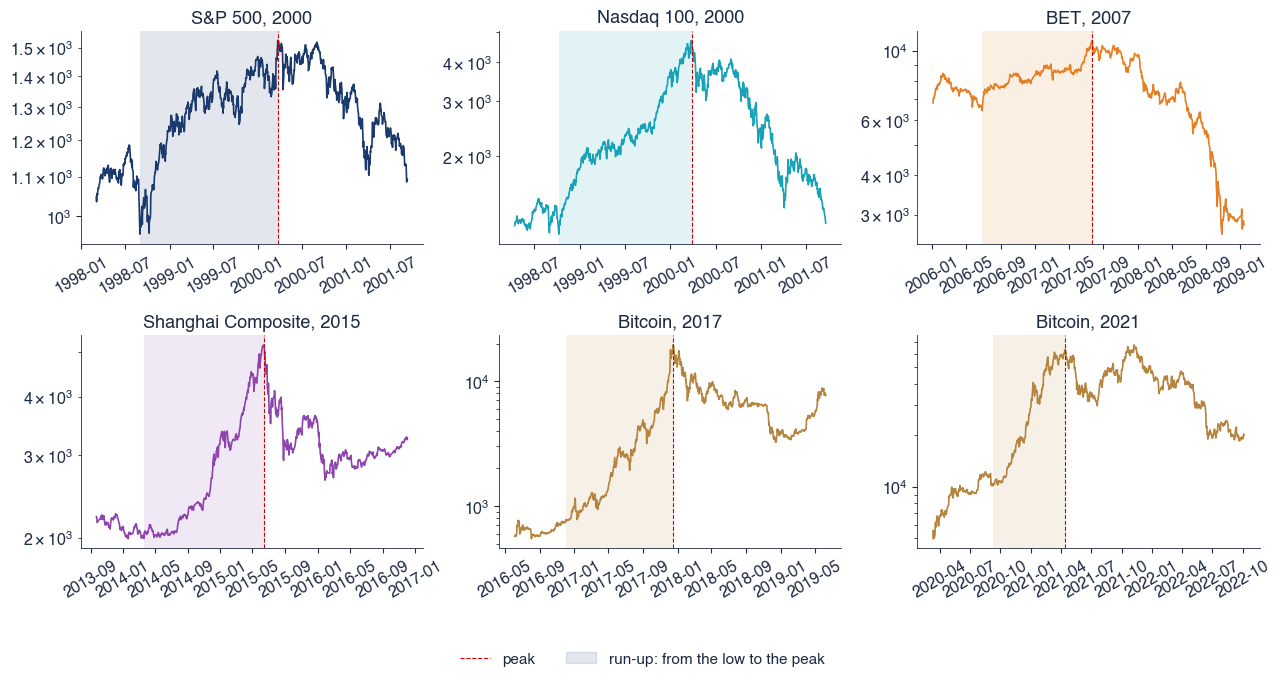

              low        peak      runup    growth    fall1y
sp500  1998-08-31  2000-03-24   0.595625  0.298894 -0.268341
ndx    1998-10-08  2000-03-27   3.167609  0.972643 -0.658845
bet    2006-06-27  2007-07-24   0.679669  0.483208 -0.496767
ssec   2014-03-20  2015-06-12   1.591625   0.77466  -0.48597
btc17  2016-12-01  2017-12-16  24.763835   3.12286  -0.83399
btc21  2020-09-08  2021-04-13   5.267912  3.089381 -0.530619


In [7]:
def fig_episodes(save_it=True):
    """Six run-ups and crashes: log price from the low before the run-up to 18 months after the peak."""
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.6))
    out = {}
    for ax, (k, e) in zip(axes.ravel(), EPISODES.items()):
        s, low, peak, _ = episode(k)
        x = s.loc[low - pd.Timedelta(days=180):peak + pd.Timedelta(days=540)]
        ax.plot(x.index, x.values, color=COLORS[k], lw=1.2, label=e['label'])
        ax.set_yscale('log')
        ax.axvspan(low, peak, color=COLORS[k], alpha=0.12, lw=0)
        ax.axvline(peak, color=st.IDAred, ls='--', lw=0.8)
        ax.set_title(e['label'])
        ax.tick_params(axis='x', labelrotation=30)
        after = s.loc[peak:peak + pd.Timedelta(days=365)]
        out[k] = dict(low=d2s(low), peak=d2s(peak), p_low=float(s[low]), p_peak=float(s[peak]),
                      runup=float(s[peak] / s[low] - 1), years=float((peak - low).days / 365.25),
                      growth=float(np.log(s[peak] / s[low]) / ((peak - low).days / 365.25)),
                      fall1y=float(after.min() / s[peak] - 1), trough=d2s(after.idxmin()))
    h = [plt.Line2D([], [], color=st.IDAred, ls='--', lw=0.8), plt.Rectangle((0, 0), 1, 1, color=st.MainBlue, alpha=0.12)]
    st.fig_legend_bottom(fig, h, ['peak', 'run-up: from the low to the peak'], ncol=2, y=0.02)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    save('tsa_ch13_episodes', save_it)
    return out


ep = fig_episodes(save_it=False)
print(pd.DataFrame(ep).T[['low', 'peak', 'runup', 'growth', 'fall1y']].round(3))

## 2. Rational bubbles and explosive roots

- A Blanchard–Watson bubble; stationary, unit-root and explosive AR(1).

{'r': 0.02, 'pi': 0.98, 'g': 0.04081632653061229, 'dur': 49.99999999999996, 'half': 34.309618491520645}


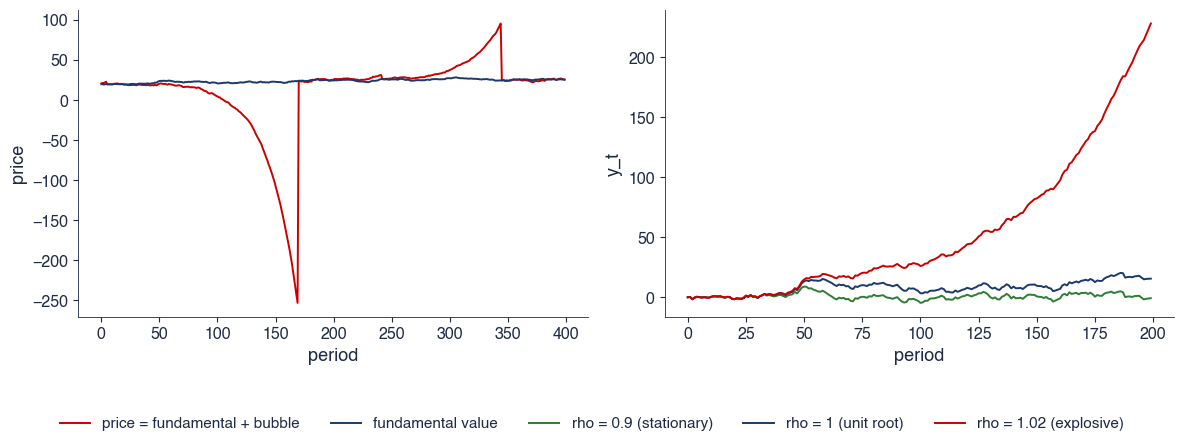

{'bw_max': 71.08659993191469, 'bw_bursts': 2, 'ar_end': {'0.9': -0.7942153003468151, '1.0': 15.517463822041723, '1.02': 227.99480875247258}, 'g100': 7.244646118252348, 'g35': 35.0027887811465}


In [8]:
def fig_rational(save_it=True):
    """Left: price = fundamental + Blanchard-Watson bubble; right: stationary, unit-root and explosive AR(1)."""
    T = 400
    rng = np.random.default_rng(SEED)
    fund = 20 + np.cumsum(0.3 * rng.standard_normal(T))
    b = blanchard_watson(T)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    axes[0].plot(fund + b, color=st.IDAred, label='price = fundamental + bubble')
    axes[0].plot(fund, color=st.MainBlue, label='fundamental value')
    axes[0].set_xlabel('period')
    axes[0].set_ylabel('price')
    P = ar1_paths()
    lab = {0.9: 'rho = 0.9 (stationary)', 1.0: 'rho = 1 (unit root)', 1.02: 'rho = 1.02 (explosive)'}
    for (rho, y), c in zip(P.items(), (st.Forest, st.MainBlue, st.IDAred)):
        axes[1].plot(y, color=c, label=lab[rho])
    axes[1].set_xlabel('period')
    axes[1].set_ylabel('y_t')
    st.fig_legend_bottom(fig, ncol=5, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('tsa_ch13_rational', save_it)
    bursts = int(np.sum((np.abs(b[1:]) < 1.5) & (b[:-1] > 4)))
    return dict(bw_max=float(b.max()), bw_bursts=bursts, ar_end={str(k): float(v[-1]) for k, v in P.items()},
                g100=float(1.02 ** 100), g35=float(np.log(2) / np.log(1.02)))


print(worked_examples()['bw'])
print(fig_rational(save_it=False))

## 3. Right-tailed unit-root tests: SADF, GSADF, BSADF

- Weekly log prices; critical values by Monte Carlo (1000 random walks with a weak drift).
- The worked example: the BSADF window of the Nasdaq 100 at the week of the peak.

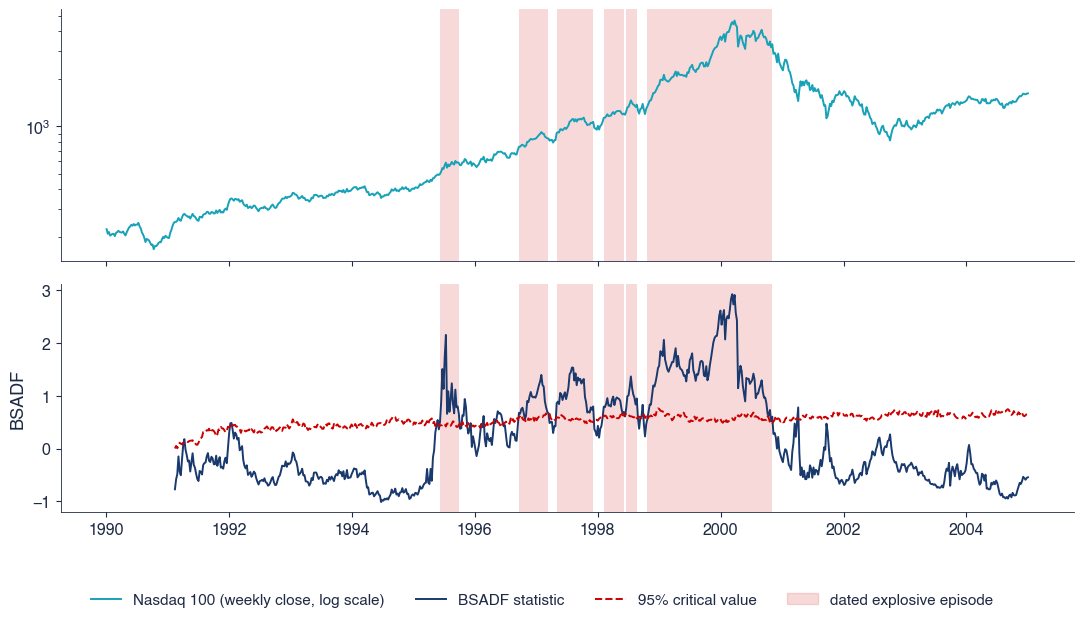

{'adf': -1.2719472977682977, 'sadf': 2.7219107900203587, 'gsadf': 2.9249623593576977, 'cv': {'adf': {90: -0.39585124041843833, 95: -0.1324081142902484, 99: 0.6090485282472361}, 'sadf': {90: 1.2353635021483493, 95: 1.4813291619547981, 99: 1.9200965042727216}, 'gsadf': {90: 2.027549142942629, 95: 2.2759389560046013, 99: 2.860963460103571}}}
[('1995-06-09', '1995-09-29', 17), ('1996-09-20', '1997-03-14', 26), ('1997-05-02', '1997-12-05', 32), ('1998-02-06', '1998-06-05', 18), ('1998-06-19', '1998-08-21', 10), ('1998-10-23', '2000-11-03', 107)]
{'a': -0.03357336780626173, 'delta': 0.0060302509505973274, 'se': 0.0020719236040084013, 't': 2.910460085946719, 'n': 427, 'start': '1992-01-17', 'end': '2000-03-24', 'bsadf': 2.9104600859462613, 'cv': 0.5420000857057908}


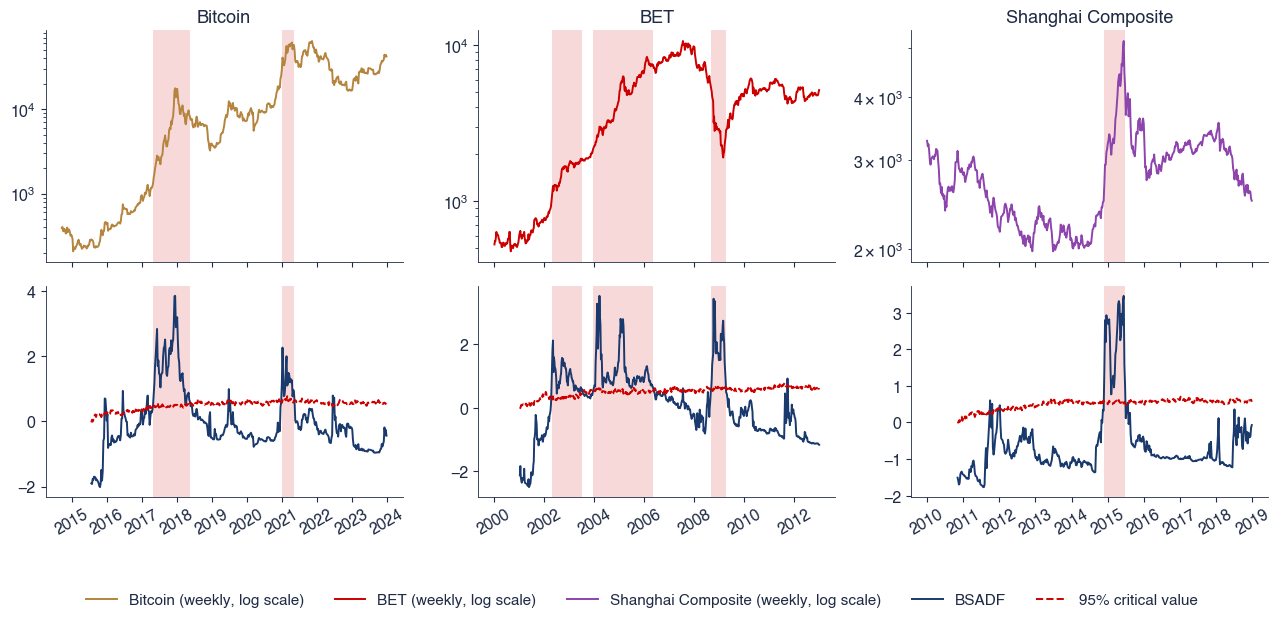

{'btc': (3.85, 2.18, [('2017-04-28', '2018-05-18', 56), ('2021-01-01', '2021-05-07', 19)]), 'bet': (3.53, 2.29, [('2002-04-19', '2003-07-11', 62), ('2003-12-19', '2006-05-12', 121), ('2008-09-05', '2009-04-03', 30)]), 'ssec': (3.46, 2.15, [('2014-11-28', '2015-06-26', 31)])}


In [9]:
def fig_psy_ndx(save_it=True):
    """Nasdaq 100, weekly 1990-2004: log price with the dated episodes, BSADF against its 95% critical values."""
    y, o, cv, ep, min_len = run_psy('ndx')
    idx = y.index[1:]
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw=dict(height_ratios=[1.1, 1]))
    axes[0].plot(y.index, np.exp(y.values), color=st.Teal, label='Nasdaq 100 (weekly close, log scale)')
    axes[0].set_yscale('log')
    for a, b, _ in ep:
        for ax in axes:
            ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=st.IDAred, alpha=0.15, lw=0)
    axes[1].plot(idx, o['bsadf'], color=st.MainBlue, label='BSADF statistic')
    axes[1].plot(idx, cv['bsadf95'], color=st.IDAred, ls='--', label='95% critical value')
    axes[1].set_ylabel('BSADF')
    h, l = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h + h2 + [plt.Rectangle((0, 0), 1, 1, color=st.IDAred, alpha=0.15)],
                         l + l2 + ['dated explosive episode'], ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch13_psy_ndx', save_it)
    # the worked example: at the week of the peak (24 March 2000), the start point that gives the BSADF value
    e = int(y.index[1:].get_indexer([pd.Timestamp('2000-03-24')])[0])
    stat = _adf_end(_cums(y.values), e, np.arange(0, e - o['w0'] + 2))[0]
    s0 = int(np.argmax(stat))
    ex = adf_window(y.values[s0:e + 2])
    ex.update(start=d2s(y.index[s0]), end=d2s(y.index[e + 1]), bsadf=float(stat.max()), cv=float(cv['bsadf95'][e]))
    return dict(T=o['n'], w0=o['w0'], r0=o['r0'], adf=o['adf'], sadf=o['sadf'], gsadf=o['gsadf'],
                cv={k: cv[k] for k in ('adf', 'sadf', 'gsadf')}, episodes=ep, min_len=min_len, example=ex,
                start=d2s(y.index[0]), end=d2s(y.index[-1]))


def fig_psy_panel(save_it=True):
    """Bitcoin, BET and the Shanghai Composite (weekly): log price with dated episodes and BSADF."""
    fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex='col', gridspec_kw=dict(height_ratios=[1.1, 1]))
    out = {}
    for j, (k, c) in enumerate([('btc', st.COL['btc']), ('bet', st.COL['bet']), ('ssec', st.Purple)]):
        y, o, cv, ep, min_len = run_psy(k)
        axes[0, j].plot(y.index, np.exp(y.values), color=c, label=f'{PSY_LABEL[k]} (weekly, log scale)')
        axes[0, j].set_yscale('log')
        axes[0, j].set_title(PSY_LABEL[k])
        axes[1, j].plot(y.index[1:], o['bsadf'], color=st.MainBlue, label='BSADF' if j == 0 else '_')
        axes[1, j].plot(y.index[1:], cv['bsadf95'], color=st.IDAred, ls='--', label='95% critical value' if j == 0 else '_')
        for a, b, _ in ep:
            for ax in axes[:, j]:
                ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=st.IDAred, alpha=0.15, lw=0)
        for ax in axes[:, j]:
            ax.tick_params(axis='x', labelrotation=30)
        out[k] = dict(T=o['n'], gsadf=o['gsadf'], cv95=cv['gsadf'][95], sadf=o['sadf'], sadf95=cv['sadf'][95],
                      episodes=ep, min_len=min_len, start=d2s(y.index[0]), end=d2s(y.index[-1]))
    st.fig_legend_bottom(fig, ncol=6, y=0.02)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch13_psy_panel', save_it)
    return out


pn = fig_psy_ndx(save_it=False)
print({k: pn[k] for k in ('adf', 'sadf', 'gsadf', 'cv')})
print(pn['episodes'])
print(pn['example'])
pp = fig_psy_panel(save_it=False)
print({k: (round(v['gsadf'], 2), round(v['cv95'], 2), v['episodes']) for k, v in pp.items()})

## 4. The LPPL model

- Exponential and super-exponential growth; the pieces of the LPPL equation.

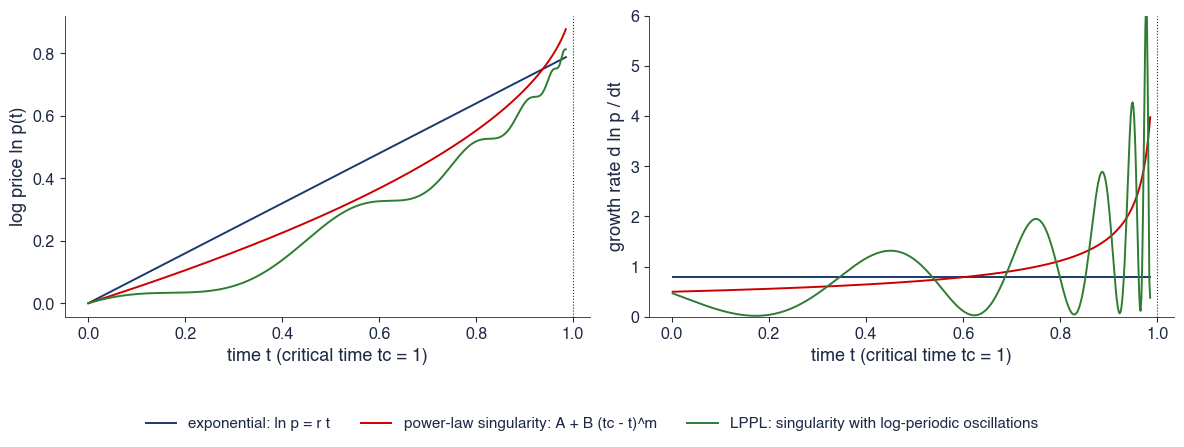

{'g_start': 0.5002057200968083, 'g_mid': 0.7018626366198838, 'g_end': 3.9763377172077834}


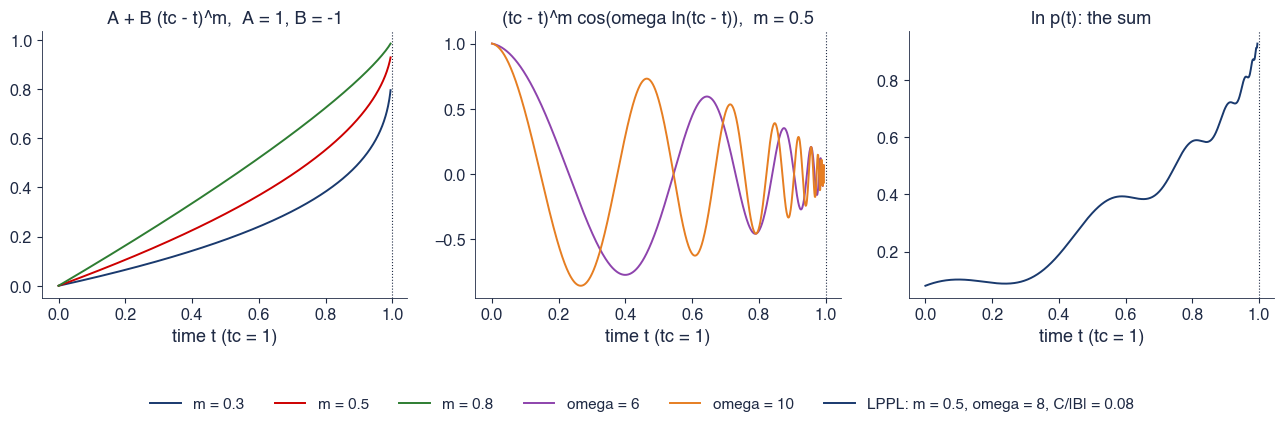

{'lam': {'6': 2.849653908226361, '6.28': 2.719660930189933, '8': 2.1932800507380152, '10': 1.8744560875853382}, 'peaks8': [0.0, 0.5440618722340038, 0.7921204236492381, 0.9052197751578451]}
{'dt': 0.25, 'fm': 0.5, 'lg': -1.3862943611198906, 'cos': 0.09463875703998736, 'lnp': 7.4037855502816}


In [10]:
def fig_growth(save_it=True):
    """Exponential growth, a power-law singularity (super-exponential) and LPPL: log price and its growth rate."""
    tc = 1.0
    t = np.linspace(0, 0.985, 600)
    expo = 0.8 * t
    sing = 1.0 - 1.0 * (tc - t) ** 0.5
    lppl = sing + 0.06 * (tc - t) ** 0.5 * np.cos(8 * np.log(tc - t))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for yv, lab, c in [(expo, 'exponential: ln p = r t', st.MainBlue), (sing, 'power-law singularity: A + B (tc - t)^m',
                                                                         st.IDAred),
                       (lppl, 'LPPL: singularity with log-periodic oscillations', st.Forest)]:
        axes[0].plot(t, yv - yv[0], color=c, label=lab)
        axes[1].plot(t[1:], np.diff(yv) / np.diff(t), color=c, label='_' + lab)
    for ax in axes:
        ax.axvline(tc, color=st.DarkText, ls=':', lw=0.8)
        ax.set_xlabel('time t (critical time tc = 1)')
    axes[0].set_ylabel('log price ln p(t)')
    axes[1].set_ylabel('growth rate d ln p / dt')
    axes[1].set_ylim(0, 6)
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('tsa_ch13_growth', save_it)
    g = np.diff(sing) / np.diff(t)
    return dict(g_start=float(g[0]), g_mid=float(g[len(g) // 2]), g_end=float(g[-1]))


def fig_lppl_components(save_it=True):
    """The pieces of the LPPL equation: power law for three values of m, the log-periodic oscillation, the sum."""
    tc = 1.0
    t = np.linspace(0, 0.995, 800)
    dt = tc - t
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for m, c in zip((0.3, 0.5, 0.8), (st.MainBlue, st.IDAred, st.Forest)):
        axes[0].plot(t, 1 - dt ** m, color=c, label=f'm = {m}')
    axes[0].set_title('A + B (tc - t)^m,  A = 1, B = -1')
    for w, c in zip((6, 10), (st.Purple, st.Orange)):
        axes[1].plot(t, dt ** 0.5 * np.cos(w * np.log(dt)), color=c, label=f'omega = {w}')
    axes[1].set_title('(tc - t)^m cos(omega ln(tc - t)),  m = 0.5')
    full = 1 - dt ** 0.5 + 0.08 * dt ** 0.5 * np.cos(8 * np.log(dt))
    axes[2].plot(t, full, color=st.MainBlue, label='LPPL: m = 0.5, omega = 8, C/|B| = 0.08')
    axes[2].set_title('ln p(t): the sum')
    for ax in axes:
        ax.axvline(tc, color=st.DarkText, ls=':', lw=0.8)
        ax.set_xlabel('time t (tc = 1)')
    st.fig_legend_bottom(fig, ncol=6, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('tsa_ch13_lppl_components', save_it)
    lam = {str(w): float(np.exp(2 * np.pi / w)) for w in (6, 6.28, 8, 10)}
    # successive local maxima of cos(omega ln(tc - t)) (phase 0): tc - t_n = exp(-2 pi n / omega)
    peaks = [float(tc - np.exp(-2 * np.pi * k / 8)) for k in range(0, 4)]
    return dict(lam=lam, peaks8=peaks)


print(fig_growth(save_it=False))
print(fig_lppl_components(save_it=False))
print(worked_examples()['1.75'])

## 5. Estimation

- First a check on simulated data: does the estimator recover known parameters?
- Then the cost landscape of the Nasdaq 100 and the fits 30 days before six peaks.

In [11]:
# A check of the estimator on simulated data: an LPPL path with known parameters plus noise
rng = np.random.default_rng(SEED)
true = dict(A=8.0, B=-0.6, C1=0.03, C2=0.02, tc=2.0, m=0.45, w=8.0)
t = np.linspace(0.0, 1.9, 500)                            # the window ends 0.1 years before tc
y = lppl_design(t, true['tc'], true['m'], true['w']) @ np.array([true['A'], true['B'], true['C1'], true['C2']])
y_obs = y + 0.01 * rng.standard_normal(len(t))
fit = lppl_fit(t, y_obs)
print({k: round(fit[k], 3) for k in ('tc', 'm', 'w', 'A', 'B', 'C1', 'C2')})
print('conditions:', lppl_conditions(fit))

{'tc': 1.999, 'm': 0.51, 'w': 7.802, 'A': 7.938, 'B': -0.534, 'C1': 0.031, 'C2': 0.017}


conditions: {'B': True, 'm': True, 'w': True, 'tc': True, 'osc': True, 'damping': True, 'rel_err': True, 'lomb': True, 'ar1': True}


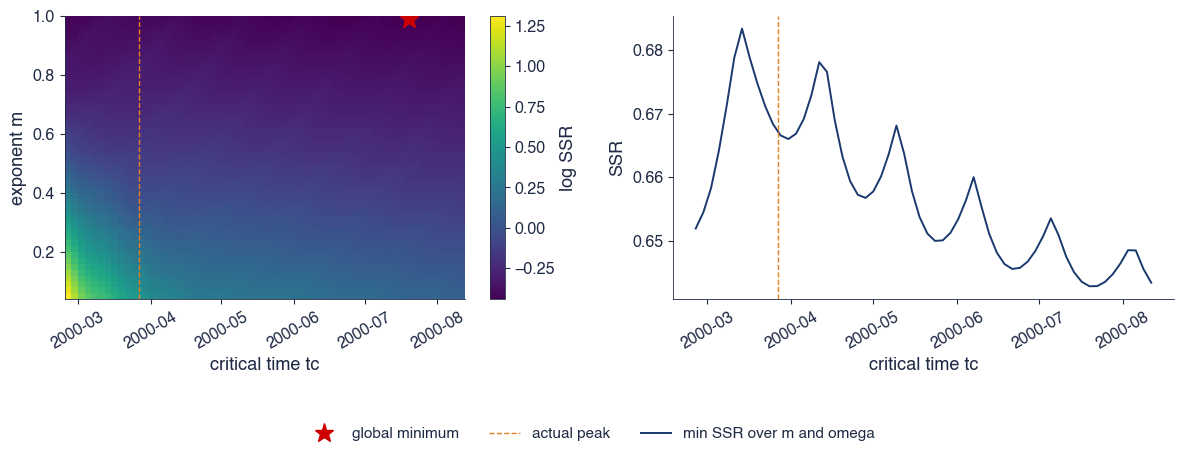

{'n_grid': 135360, 'tc_best': '2000-07-19', 'm_best': 0.99, 'locmin': 5, 'ssr_ratio': 1.0630394445054472}


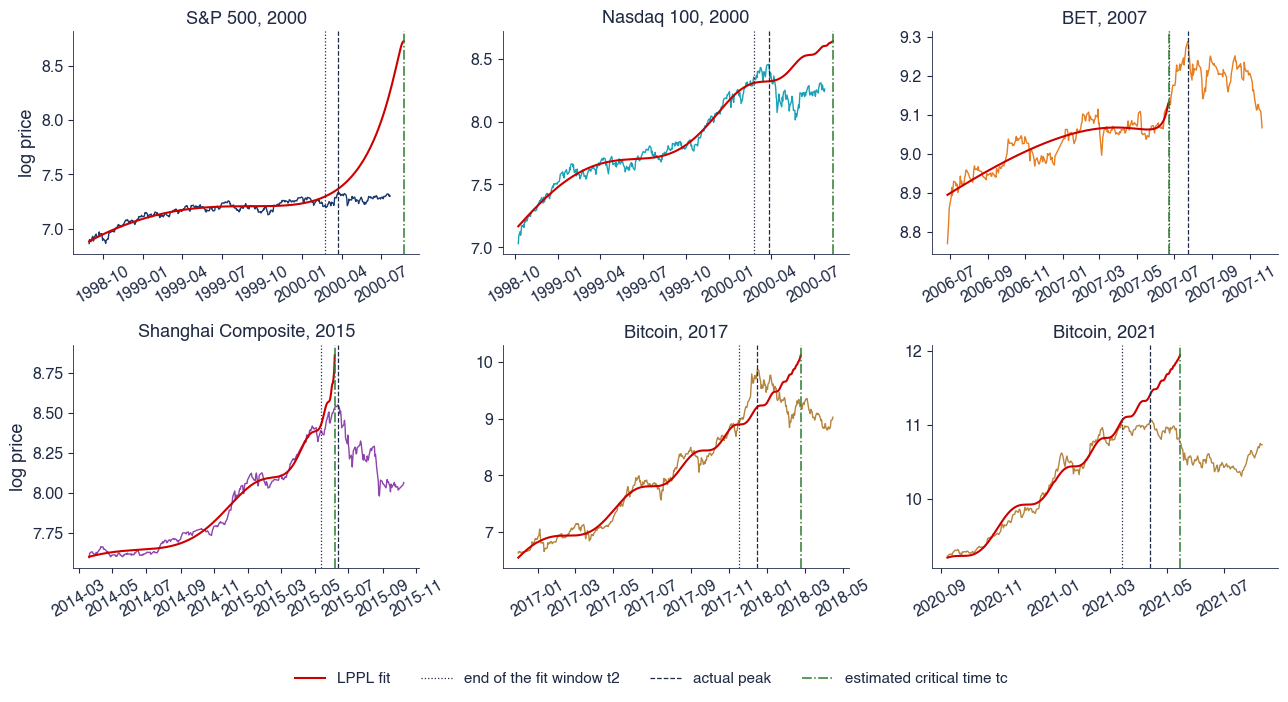

               t2          tc tc_err         m          w q_param q_full
sp500  2000-02-23  2000-08-21    150     0.999        1.0   False  False
ndx    2000-02-25  2000-08-11    137     0.999   5.860219   False  False
bet    2007-06-22  2007-06-22    -32  0.685546        1.0   False  False
ssec   2015-05-13  2015-06-06     -6  0.391881    5.49705    True   True
btc17  2017-11-16  2018-02-22     68  0.713846  14.066665   False  False
btc21  2021-03-14  2021-05-15     32  0.816732  17.382508   False  False


In [12]:
def fig_cost(save_it=True):
    """Why estimation is hard: SSR as a function of (tc, m) with omega profiled out, Nasdaq 100 window before the
    peak; and the profile of SSR over tc."""
    s, low, peak, t2 = episode('ndx')
    x = s.loc[low:t2]
    t, y = yrs(x.index), np.log(x.values)
    D = t[-1] - t[0]
    tcs = np.linspace(t[-1] + 0.002, t[-1] + D / 3, 60)
    ms = np.linspace(0.05, 0.99, 48)
    ws = np.linspace(2, 25, 47)
    TC, M, W, beta, ssr = _grid(t, y, tcs, ms, ws)
    S = ssr.reshape(len(tcs), len(ms), len(ws)).min(axis=2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
    im = axes[0].pcolormesh([todate(v) for v in tcs], ms, np.log(S.T), cmap='viridis', shading='auto')
    fig.colorbar(im, ax=axes[0], label='log SSR')
    i, j = np.unravel_index(np.argmin(S), S.shape)
    axes[0].plot([todate(tcs[i])], [ms[j]], marker='*', color=st.IDAred, ms=14, ls='', label='global minimum')
    axes[0].axvline(peak, color=st.Orange, ls='--', lw=1, label='actual peak')
    axes[0].set_xlabel('critical time tc')
    axes[0].set_ylabel('exponent m')
    axes[0].tick_params(axis='x', labelrotation=30)
    prof = S.min(axis=1)
    axes[1].plot([todate(v) for v in tcs], prof, color=st.MainBlue, label='min SSR over m and omega')
    axes[1].axvline(peak, color=st.Orange, ls='--', lw=1, label='_')
    axes[1].set_xlabel('critical time tc')
    axes[1].set_ylabel('SSR')
    axes[1].tick_params(axis='x', labelrotation=30)
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('tsa_ch13_cost', save_it)
    # local minima of the profile (a rugged landscape)
    locmin = int(np.sum((prof[1:-1] < prof[:-2]) & (prof[1:-1] < prof[2:])))
    return dict(n_grid=int(len(tcs) * len(ms) * len(ws)), tc_best=d2s(todate(tcs[i])), m_best=float(ms[j]),
                locmin=locmin, ssr_ratio=float(prof.max() / prof.min()))


def fig_fits(save_it=True):
    """Ex-ante LPPL fits: window from the low before the run-up to 30 days before the peak; fitted path extrapolated
    to the estimated critical time; actual peak."""
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.8))
    out = {}
    for ax, (k, e) in zip(axes.ravel(), EPISODES.items()):
        s, low, peak, t2 = episode(k)
        f = fit_window(s, low, t2)
        c = lppl_conditions(f)
        x = s.loc[low:peak + pd.Timedelta(days=120)]
        ax.plot(x.index, np.log(x.values), color=COLORS[k], lw=1.0, label='_' + e['label'])
        tt = np.linspace(f['t1'], min(f['tc'], f['t2'] + 0.6) - 1e-4, 400)
        ax.plot([todate(v) for v in tt], lppl_path(f, tt), color=st.IDAred, lw=1.5, label='LPPL fit' if k == 'sp500' else '_')
        ax.axvline(t2, color=st.DarkText, ls=':', lw=0.9, label='end of the fit window t2' if k == 'sp500' else '_')
        ax.axvline(peak, color=st.DarkText, ls='--', lw=0.9, label='actual peak' if k == 'sp500' else '_')
        ax.axvline(todate(f['tc']), color=st.Forest, ls='-.', lw=1.1, label='estimated critical time tc' if k == 'sp500' else '_')
        ax.set_title(e['label'])
        ax.tick_params(axis='x', labelrotation=30)
        out[k] = dict(t1=d2s(low), t2=d2s(t2), peak=d2s(peak), n=f['n'], tc=d2s(todate(f['tc'])),
                      tc_err=int((todate(f['tc']) - peak).days), **{p: f[p] for p in ('m', 'w', 'A', 'B', 'C1', 'C2', 'C', 'damping', 'osc', 'rel_err', 'rmse')},
                      cond={kk: (None if v is None else bool(v)) for kk, v in c.items()},
                      q_param=qualified(c, 'param'), q_full=qualified(c, 'full'))
    axes[0, 0].set_ylabel('log price')
    axes[1, 0].set_ylabel('log price')
    st.fig_legend_bottom(fig, ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    save('tsa_ch13_fits', save_it)
    # worked example: the fitted value at t2 for the Shanghai Composite, term by term
    s, low, peak, t2 = episode('ssec')
    f = fit_window(s, low, t2)
    tt = f['t2']
    dt = f['tc'] - tt
    fm = dt ** f['m']
    out['example'] = dict(t2=tt, dt=dt, A=f['A'], B=f['B'], C1=f['C1'], C2=f['C2'], m=f['m'], w=f['w'], tc=f['tc'], fm=fm, lg=float(np.log(dt)), cos=float(np.cos(f['w'] * np.log(dt))),
                          sin=float(np.sin(f['w'] * np.log(dt))), lnp_hat=float(lppl_path(f, [tt])[0]),
                          lnp=float(np.log(s.loc[t2])), p=float(s.loc[t2]), p_hat=float(np.exp(lppl_path(f, [tt])[0])))
    return out


print(fig_cost(save_it=False))
fits = fig_fits(save_it=False)
print(pd.DataFrame({k: v for k, v in fits.items() if k != 'example'}).T[['t2', 'tc', 'tc_err', 'm', 'w', 'q_param', 'q_full']])

## 6. Confidence from many windows

- 29 windows ending at one date; the critical time as the window end moves; the indicator around four peaks (read from the cached series).

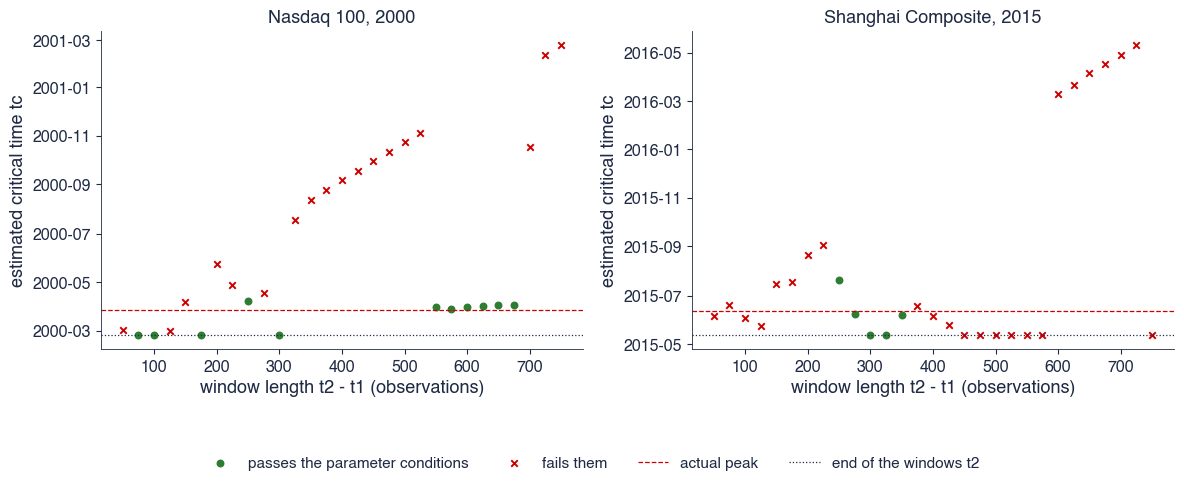

{'ndx': {'t2': '2000-02-25', 'peak': '2000-03-27', 'n': 29, 'n_param': 11, 'n_full': 1, 'ci_param': 0.3793103448275862, 'ci_full': 0.034482758620689655, 'shares': {'B': 1.0, 'm': 0.6896551724137931, 'w': 1.0, 'tc': 0.5517241379310345, 'osc': 0.9655172413793104, 'damping': 1.0, 'rel_err': 0.4482758620689655}, 'tc_q10': '2000-02-25', 'tc_q50': '2000-03-30', 'tc_q90': '2000-04-02'}, 'ssec': {'t2': '2015-05-13', 'peak': '2015-06-12', 'n': 29, 'n_param': 5, 'n_full': 2, 'ci_param': 0.1724137931034483, 'ci_full': 0.06896551724137931, 'shares': {'B': 0.9310344827586207, 'm': 0.41379310344827586, 'w': 0.6206896551724138, 'tc': 0.5862068965517241, 'osc': 0.7241379310344828, 'damping': 1.0, 'rel_err': 0.896551724137931}, 'tc_q10': '2015-05-13', 'tc_q50': '2015-06-06', 'tc_q90': '2015-07-03'}}


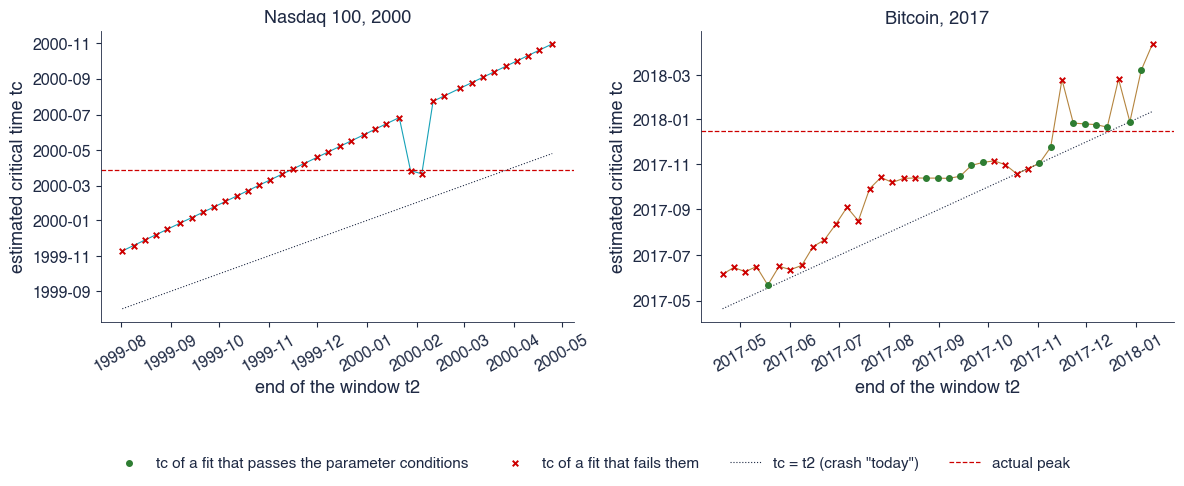

{'ndx': {'n': 38, 'share_q': 0.0, 'tc_min': '1999-11-09', 'tc_max': '2000-10-30', 'err_med': 81.0, 'range_days': 356}, 'btc17': {'n': 39, 'share_q': 0.38461538461538464, 'tc_min': '2017-05-21', 'tc_max': '2018-04-12', 'err_med': 65.0, 'range_days': 325}}


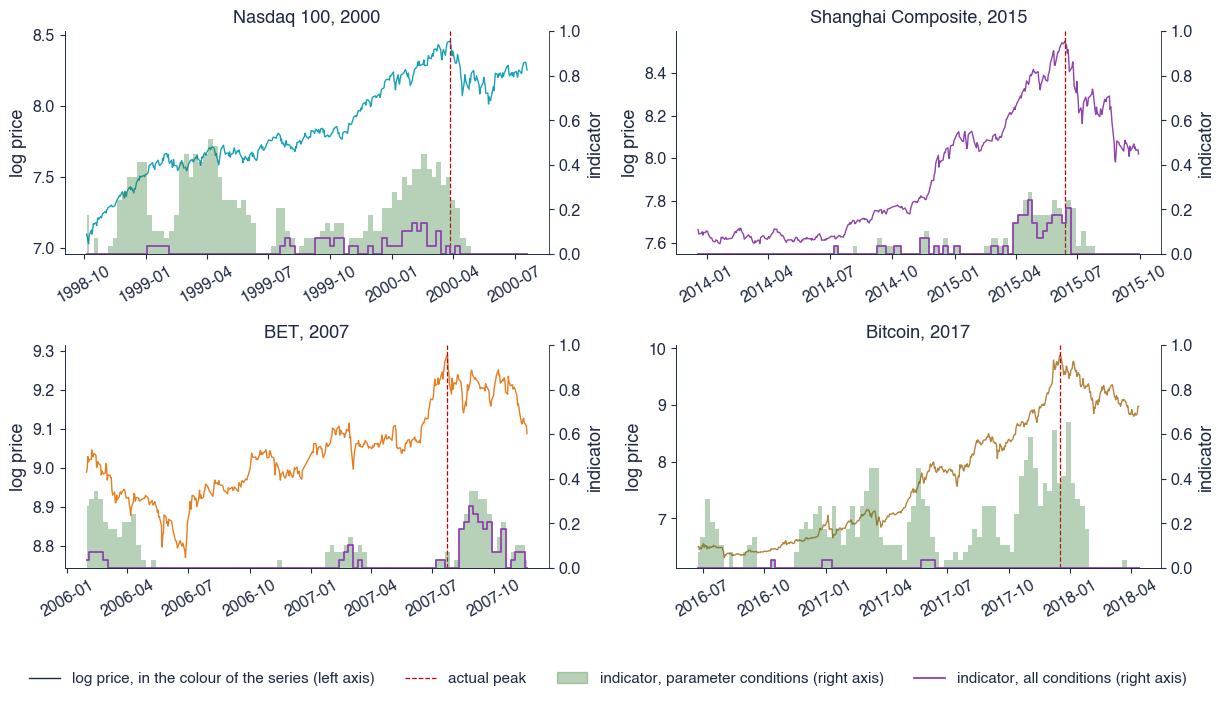

{'ndx': {'max_param': 0.5172, 'max_param_d': '1999-04-07', 'max_full': 0.1379, 'max_full_d': '2000-02-03', 'pre_param': 0.37498750000000003, 'first_alarm': '1998-11-23', 'peak': '2000-03-27'}, 'ssec': {'max_param': 0.2759, 'max_param_d': '2015-04-22', 'max_full': 0.2414, 'max_full_d': '2015-04-22', 'pre_param': 0.19396249999999998, 'first_alarm': '2015-04-15', 'peak': '2015-06-12'}, 'bet': {'max_param': 0.3448, 'max_param_d': '2006-02-13', 'max_full': 0.2759, 'max_full_d': '2007-08-28', 'pre_param': 0.01725, 'first_alarm': '2006-01-30', 'peak': '2007-07-24'}, 'btc17': {'max_param': 0.6552, 'max_param_d': '2017-12-29', 'max_full': 0.0345, 'max_full_d': '2016-10-14', 'pre_param': 0.43966249999999996, 'first_alarm': '2016-07-08', 'peak': '2017-12-16'}}


In [13]:
def fig_windows(save_it=True):
    """Many windows, one end date: estimated tc against the window length (Nasdaq 100 2000, Shanghai 2015)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    out = {}
    for ax, k in zip(axes, ('ndx', 'ssec')):
        d, peak, t2 = windows_at(k)
        ax.scatter(d.loc[d['q_param'], 'L'], d.loc[d['q_param'], 'tc'], color=st.Forest, s=22,
                   label='passes the parameter conditions' if k == 'ndx' else '_')
        ax.scatter(d.loc[~d['q_param'], 'L'], d.loc[~d['q_param'], 'tc'], color=st.IDAred, marker='x', s=22,
                   label='fails them' if k == 'ndx' else '_')
        ax.axhline(peak, color=st.IDAred, ls='--', lw=0.9, label='actual peak' if k == 'ndx' else '_')
        ax.axhline(t2, color=st.DarkText, ls=':', lw=0.9, label='end of the windows t2' if k == 'ndx' else '_')
        ax.set_title(EPISODES[k]['label'])
        ax.set_xlabel('window length t2 - t1 (observations)')
        ax.set_ylabel('estimated critical time tc')
        q = d[d['q_param']]
        shares = {c: float(d['c_' + c].fillna(False).astype(bool).mean()) for c in ('B', 'm', 'w', 'tc', 'osc', 'damping', 'rel_err')}
        out[k] = dict(t2=d2s(t2), peak=d2s(peak), n=int(len(d)), n_param=int(len(q)), n_full=int(d['q_full'].sum()),
                      ci_param=float(d['q_param'].mean()), ci_full=float(d['q_full'].mean()), shares=shares,
                      tc_q10=d2s(q['tc'].quantile(0.1)) if len(q) else None, tc_q50=d2s(q['tc'].quantile(0.5)) if len(q) else None,
                      tc_q90=d2s(q['tc'].quantile(0.9)) if len(q) else None)
    st.fig_legend_bottom(fig, ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch13_windows', save_it)
    return out


def fig_tc_path(save_it=True):
    """The critical time is unstable: estimated tc against the end of the window, Nasdaq 100 2000 and Bitcoin 2017."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    out = {}
    for ax, k in zip(axes, ('ndx', 'btc17')):
        d, peak = tc_path(k)
        ax.plot(d['t2'], d['tc'], color=COLORS[k], lw=0.8, label='_')
        ax.scatter(d.loc[d['q'], 't2'], d.loc[d['q'], 'tc'], color=st.Forest, s=16, zorder=3,
                   label='tc of a fit that passes the parameter conditions' if k == 'ndx' else '_')
        ax.scatter(d.loc[~d['q'], 't2'], d.loc[~d['q'], 'tc'], color=st.IDAred, s=16, marker='x', zorder=3,
                   label='tc of a fit that fails them' if k == 'ndx' else '_')
        ax.plot(d['t2'], d['t2'], color=st.DarkText, ls=':', lw=0.8, label='tc = t2 (crash "today")' if k == 'ndx' else '_')
        ax.axhline(peak, color=st.IDAred, ls='--', lw=0.9, label='actual peak' if k == 'ndx' else '_')
        ax.set_title(EPISODES[k]['label'])
        ax.set_xlabel('end of the window t2')
        ax.set_ylabel('estimated critical time tc')
        ax.tick_params(axis='x', labelrotation=30)
        err = (d['tc'] - peak).dt.days
        out[k] = dict(n=int(len(d)), share_q=float(d['q'].mean()), tc_min=d2s(d['tc'].min()), tc_max=d2s(d['tc'].max()),
                      err_med=float(np.median(np.abs(err))), range_days=int((d['tc'].max() - d['tc'].min()).days))
    st.fig_legend_bottom(fig, ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch13_tc_path', save_it)
    return out


def fig_ci(save_it=True):
    """LPPLS confidence indicator around four peaks: log price and the share of qualified windows (two filters)."""
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.8))
    out = {}
    for ax, k in zip(axes.ravel(), ('ndx', 'ssec', 'bet', 'btc17')):
        ci, s, peak = episode_ci(k)
        x = s.loc[ci.index[0]:ci.index[-1]]
        ax.plot(x.index, np.log(x.values), color=COLORS[k], lw=1.0, label='_')
        ax.axvline(peak, color=st.IDAred, ls='--', lw=0.9)
        ax.set_ylabel('log price')
        ax.set_title(EPISODES[k]['label'])
        ax.tick_params(axis='x', labelrotation=30)
        a2 = ax.twinx()
        a2.fill_between(ci.index, 0, ci['ci_param'], color=st.Forest, alpha=0.35, lw=0, step='mid')
        a2.plot(ci.index, ci['ci_full'], color=st.Purple, lw=1.3, drawstyle='steps-mid')
        a2.set_ylim(0, 1)
        a2.set_ylabel('indicator')
        a2.spines['right'].set_visible(True)
        pre = ci.loc[:peak]
        out[k] = dict(max_param=float(ci['ci_param'].max()), max_param_d=d2s(ci['ci_param'].idxmax()),
                      max_full=float(ci['ci_full'].max()), max_full_d=d2s(ci['ci_full'].idxmax()),
                      pre_param=float(pre['ci_param'].iloc[-8:].mean()), first_alarm=d2s(pre.index[pre['ci_param'] >= CI_LEVEL][0])
                      if (pre['ci_param'] >= CI_LEVEL).any() else None, peak=d2s(peak))
    h = [plt.Line2D([], [], color=st.DarkText, lw=1), plt.Line2D([], [], color=st.IDAred, ls='--', lw=0.9),
         plt.Rectangle((0, 0), 1, 1, color=st.Forest, alpha=0.35), plt.Line2D([], [], color=st.Purple, lw=1.3)]
    st.fig_legend_bottom(fig, h, ['log price, in the colour of the series (left axis)', 'actual peak', 'indicator, parameter conditions (right axis)',
                                  'indicator, all conditions (right axis)'], ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    save('tsa_ch13_ci', save_it)
    return out


print(fig_windows(save_it=False))
print(fig_tc_path(save_it=False))
print(fig_ci(save_it=False))

### Computing the indicator yourself

- A short stretch of Bitcoin in 2017, every 21 days, sequentially (about a minute). Change the window list or the filter and compare.

In [14]:
s17 = prices('BTC-USD.CC', crypto=True)
ci_short = confidence_series(s17, '2017-09-01', '2018-01-15', step=21, procs=1)
print(ci_short.round(3))

            ci_full  ci_param  tc_median
date                                    
2017-09-01      0.0     0.276   2017.754
2017-09-22      0.0     0.103   2017.813
2017-10-13      0.0     0.241   2017.789
2017-11-03      0.0     0.586   2017.838
2017-11-24      0.0     0.379   2017.901
2017-12-15      0.0     0.379   2017.992
2018-01-05      0.0     0.379   2018.117


## 7. An honest evaluation

- Alarms (indicator >= 0.2) against falls of at least 20% within 182 days, over the whole S&P 500 and Bitcoin samples; hit rate against the base rate.

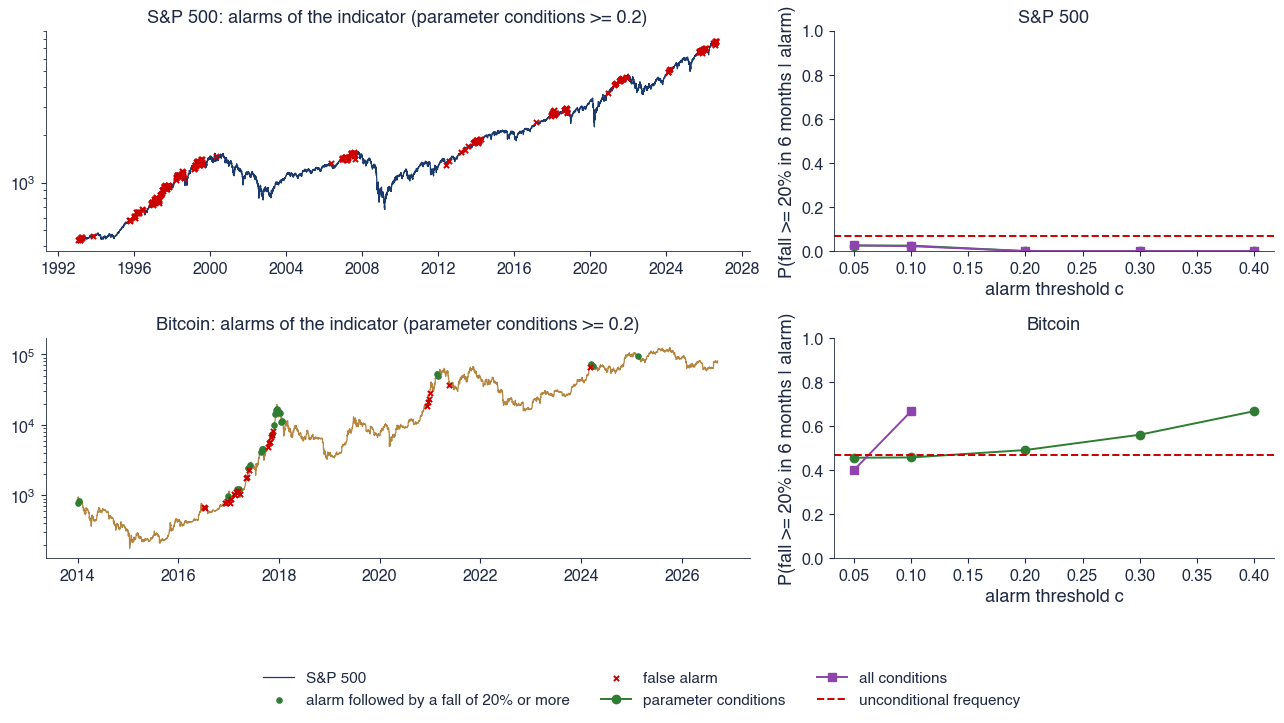

sp500 base rate 0.068 {'0.1': 0.025, '0.2': 0.0, '0.3': 0.0}
   drawdowns of 20% or more: [('2000-03-24', -0.49, False), ('2007-10-09', -0.57, True), ('2020-02-19', -0.34, False), ('2022-01-03', -0.25, True)]
btc base rate 0.467 {'0.1': 0.457, '0.2': 0.491, '0.3': 0.56}
   drawdowns of 20% or more: [('2014-01-06', -0.81, True), ('2017-01-04', -0.33, True), ('2017-03-03', -0.26, True), ('2017-06-11', -0.35, True), ('2017-09-01', -0.36, True), ('2017-11-08', -0.2, True), ('2017-12-16', -0.83, True), ('2021-01-08', -0.25, True), ('2021-02-21', -0.22, True), ('2021-04-13', -0.53, True), ('2021-11-08', -0.77, True), ('2024-03-13', -0.26, True), ('2025-01-21', -0.28, False), ('2025-10-06', -0.53, False)]


In [15]:
def fig_eval(save_it=True):
    """Honest evaluation: alarm days on the whole S&P 500 and Bitcoin samples and the hit rate by threshold."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 6.8), gridspec_kw=dict(width_ratios=[1.6, 1]))
    out = {}
    for j, (name, c, lab) in enumerate([('sp500', st.COL['sp500'], 'S&P 500'), ('btc', st.COL['btc'], 'Bitcoin')]):
        s, d = eval_ci(name)
        x = s.loc[d.index[0]:]
        ax = axes[j, 0]
        ax.plot(x.index, x.values, color=c, lw=0.9, label=f'{lab}' if j == 0 else '_')
        ax.set_yscale('log')
        al = d[d['ci_param'] >= CI_LEVEL]
        ok = al['fall'] <= -CRASH
        ax.scatter(al.index[ok], s.reindex(al.index[ok]), color=st.Forest, s=14, zorder=3,
                   label='alarm followed by a fall of 20% or more' if j == 0 else '_')
        ax.scatter(al.index[~ok], s.reindex(al.index[~ok]), color=st.IDAred, s=14, marker='x', zorder=3,
                   label='false alarm' if j == 0 else '_')
        ax.set_title(f'{lab}: alarms of the indicator (parameter conditions >= {CI_LEVEL})')
        hr = hit_rates(d)
        hrf = hit_rates(d, col='ci_full')
        lv = [k for k in hr if k not in ('base', 'n')]
        axes[j, 1].plot([float(v) for v in lv], [hr[v]['hit'] for v in lv], color=st.Forest, marker='o',
                        label='parameter conditions' if j == 0 else '_')
        axes[j, 1].plot([float(v) for v in lv], [hrf[v]['hit'] for v in lv], color=st.Purple, marker='s',
                        label='all conditions' if j == 0 else '_')
        axes[j, 1].axhline(hr['base'], color=st.IDAred, ls='--', label='unconditional frequency' if j == 0 else '_')
        axes[j, 1].set_ylim(0, 1)
        axes[j, 1].set_xlabel('alarm threshold c')
        axes[j, 1].set_ylabel('P(fall >= 20% in 6 months | alarm)')
        axes[j, 1].set_title(lab)
        ep = alarm_episodes(d)
        out[name] = dict(start=d2s(d.index[0]), end=d2s(d.index[-1]), hit=hr, hit_full=hrf, n_ep=len(ep),
                         n_ep_crash=int(sum(1 for e in ep if e['crash'])), n_ep_known=int(sum(1 for e in ep if e['crash'] is not None)),
                         episodes=[dict(first=d2s(e['first']), last=d2s(e['last']), fall=e['fall'], crash=e['crash']) for e in ep],
                         falls=crash_list(s.loc[d.index[0]:]))
        al_dates = d.index[d['ci_param'] >= CI_LEVEL]
        for f in out[name]['falls']:
            pk = pd.Timestamp(f['peak'])
            f['alarm_before'] = bool(((al_dates <= pk) & (al_dates > pk - pd.Timedelta(days=HORIZON))).any())
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('tsa_ch13_eval', save_it)
    return out


ev = fig_eval(save_it=False)
for k, v in ev.items():
    print(k, 'base rate', round(v['hit']['base'], 3), {c: round(v['hit'][c]['hit'], 3) for c in ('0.1', '0.2', '0.3')})
    print('   drawdowns of 20% or more:', [(f['peak'], round(f['fall'], 2), f['alarm_before']) for f in v['falls']])

## Exercises

1. Run `run_psy` on the weekly BET-TR (`prices('BETTR.INDX')`, since 2014): which episodes do you find?
2. Fit LPPL to Bitcoin between 1 January 2017 and 1 December 2017 and check the filter conditions one by one.
3. Replace the 15% error condition by 25% (`LPPLS_FILTER['rel_err_max']`) and recompute the indicator for Bitcoin in 2017 with `confidence_series`: how does the picture change?
4. Change the crash definition to a fall of 15% within 90 days and recompute the hit rates with `hit_rates`.